<a href="https://colab.research.google.com/github/0xjessie21/data-science-2026/blob/main/Pertemuan10_MOHAMMAD_RIYAN_SYAIFUNAHAR_240401010292.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 10 — Algoritma Klasifikasi (Bagian 2)
## Aktivitas Hands-on: Prediksi Customer Churn

**Mata Kuliah:** Data Science  
**Program Studi:** Informatika  
**Nama:** Mohammad Riyan Syaifunahar  
**NIM:** 240401010292

---

Notebook ini membangun model **Random Forest** untuk memprediksi *customer churn* pada dataset **Telco Customer Churn** yang bersifat *imbalanced* (±26,5% churn). Selain model dasar, notebook membandingkan tiga skenario penanganan ketidakseimbangan kelas: **baseline**, **class_weight='balanced'**, dan **SMOTE**, dengan fokus evaluasi pada **Recall** kelas churn.

In [1]:
!pip install -q imbalanced-learn

## Langkah 1 — Muat dan Eksplorasi Data

Dataset dibaca langsung dari sumber publik sehingga notebook dapat dijalankan tanpa upload manual. Proporsi kelas diperiksa untuk memastikan dataset bersifat *imbalanced*.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(URL)

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Tipe data per kolom:")
print(df.dtypes)
print("\nProporsi kelas target (Churn):")
print(df["Churn"].value_counts(normalize=True).round(3))

Tipe data per kolom:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Proporsi kelas target (Churn):
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


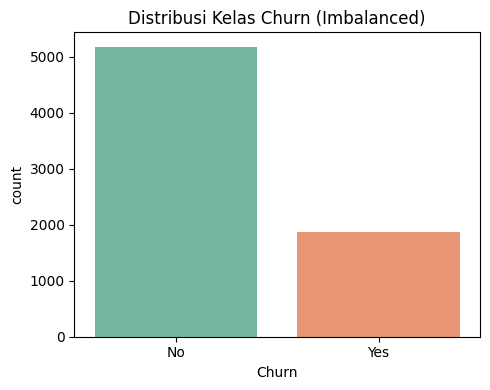

In [4]:
plt.figure(figsize=(5, 4))
sns.countplot(x="Churn", data=df, hue="Churn", palette="Set2", legend=False)
plt.title("Distribusi Kelas Churn (Imbalanced)")
plt.tight_layout()
plt.show()

## Langkah 2 — Preprocessing

Tahapan: menghapus kolom identitas, mengoreksi `TotalCharges` (memiliki nilai kosong tersembunyi) menjadi numerik, mengubah target `Churn` menjadi biner (1 = Yes, 0 = No), melakukan *one-hot encoding* pada fitur kategorikal, lalu *stratified split* 80:20.

In [5]:
df = df.drop(columns=["customerID"])
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)
df["Churn"] = (df["Churn"] == "Yes").astype(int)

y = df["Churn"]
X = pd.get_dummies(df.drop(columns=["Churn"]), drop_first=True)

print("Shape fitur setelah encoding:", X.shape)
print("Proporsi target:")
print(y.value_counts(normalize=True).round(3))

Shape fitur setelah encoding: (7032, 30)
Proporsi target:
Churn
0    0.734
1    0.266
Name: proportion, dtype: float64


In [6]:
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print("Train:", X_tr.shape, "| Test:", X_te.shape)

Train: (5625, 30) | Test: (1407, 30)


## Langkah 3 — Latih Model

Model utama menggunakan `RandomForestClassifier` dengan `class_weight="balanced"` untuk menangani ketidakseimbangan kelas pada level algoritma.

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", random_state=42)
rf.fit(X_tr, y_tr)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

## Langkah 4 — Evaluasi

Evaluasi difokuskan pada kelas churn (kelas 1) menggunakan Precision, Recall, F1-Score, dan ROC-AUC.

In [8]:
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay)

y_pred = rf.predict(X_te)
y_proba = rf.predict_proba(X_te)[:, 1]

print(classification_report(y_te, y_pred, target_names=["Tidak Churn", "Churn"]))
print("ROC-AUC:", round(roc_auc_score(y_te, y_proba), 3))

              precision    recall  f1-score   support

 Tidak Churn       0.83      0.90      0.86      1033
       Churn       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.82


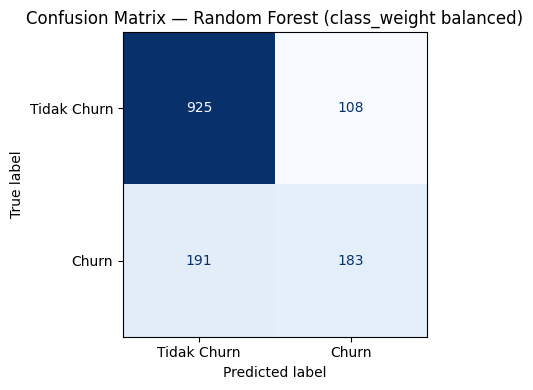

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred,
    display_labels=["Tidak Churn", "Churn"],
    cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Confusion Matrix — Random Forest (class_weight balanced)")
plt.tight_layout()
plt.show()

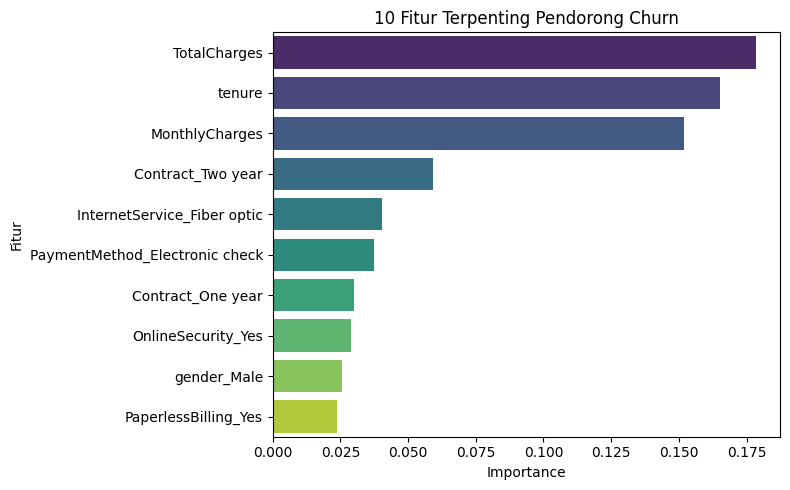

,Fitur,Importance
0,TotalCharges,0.178447
1,tenure,0.165076
2,MonthlyCharges,0.151884
3,Contract_Two year,0.059238
4,InternetService_Fiber optic,0.040405
5,PaymentMethod_Electronic check,0.037501
6,Contract_One year,0.029965
7,OnlineSecurity_Yes,0.028844
8,gender_Male,0.025493
9,PaperlessBilling_Yes,0.023603


In [10]:
importance = pd.DataFrame({
    "Fitur": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x="Importance", y="Fitur", data=importance.head(10), hue="Fitur", palette="viridis", legend=False)
plt.title("10 Fitur Terpenting Pendorong Churn")
plt.tight_layout()
plt.show()

importance.head(10).reset_index(drop=True)

## Langkah 5 — Prediksi Probabilitas, Perbandingan Skenario, dan Kesimpulan

### 5.1 Probabilitas churn per pelanggan

`predict_proba` menghasilkan probabilitas churn tiap pelanggan, berguna untuk memprioritaskan tindakan retensi pada pelanggan berisiko tertinggi.

In [11]:
hasil_proba = pd.DataFrame({
    "Probabilitas_Churn": y_proba,
    "Aktual": y_te.values
}).sort_values("Probabilitas_Churn", ascending=False).reset_index(drop=True)

print("10 pelanggan dengan risiko churn tertinggi:")
hasil_proba.head(10)

10 pelanggan dengan risiko churn tertinggi:


,Probabilitas_Churn,Aktual
0,1.000000,1
1,0.996667,1
2,0.996667,0
3,0.996667,0
4,0.996667,1
5,0.990000,1
6,0.983333,1
7,0.970000,1
8,0.963333,1
9,0.960000,0


### 5.2 Perbandingan tiga skenario penanganan imbalanced

Membandingkan **baseline**, **class_weight='balanced'**, dan **SMOTE** terhadap Recall, Precision, F1, dan ROC-AUC kelas churn. SMOTE hanya diterapkan pada data latih.

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

def evaluasi(model, label):
    proba = model.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "Skenario": label,
        "Precision": round(precision_score(y_te, pred), 3),
        "Recall": round(recall_score(y_te, pred), 3),
        "F1-Score": round(f1_score(y_te, pred), 3),
        "ROC-AUC": round(roc_auc_score(y_te, proba), 3),
    }

rf_base = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_tr, y_tr)

X_res, y_res = SMOTE(random_state=42).fit_resample(X_tr, y_tr)
rf_smote = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_res, y_res)

ringkasan = pd.DataFrame([
    evaluasi(rf_base, "Baseline"),
    evaluasi(rf, "Class Weight Balanced"),
    evaluasi(rf_smote, "SMOTE"),
]).set_index("Skenario")
ringkasan

,Precision,Recall,F1-Score,ROC-AUC
Skenario,,,,
Baseline,0.630,0.519,0.569,0.819
Class Weight Balanced,0.627,0.495,0.553,0.820
SMOTE,0.579,0.610,0.594,0.818


### 5.3 Threshold tuning

Menurunkan ambang keputusan dari 0,5 ke 0,35 untuk menangkap lebih banyak pelanggan berisiko (meningkatkan Recall).

In [13]:
proba_smote = rf_smote.predict_proba(X_te)[:, 1]
for thr in [0.5, 0.4, 0.35, 0.3]:
    pred_thr = (proba_smote >= thr).astype(int)
    print(f"Threshold {thr}: Recall={recall_score(y_te, pred_thr):.3f} | "
          f"Precision={precision_score(y_te, pred_thr):.3f} | "
          f"F1={f1_score(y_te, pred_thr):.3f}")

Threshold 0.5: Recall=0.610 | Precision=0.579 | F1=0.594
Threshold 0.4: Recall=0.701 | Precision=0.522 | F1=0.598
Threshold 0.35: Recall=0.741 | Precision=0.495 | F1=0.593
Threshold 0.3: Recall=0.807 | Precision=0.478 | F1=0.600


### 5.4 Kesimpulan

Random Forest mampu memeringkat risiko churn dengan baik (ROC-AUC ±0,82), namun dengan ambang default 0,5 Recall kelas churn masih rendah karena dataset *imbalanced* — banyak pelanggan berisiko yang terlewat (False Negative tinggi). Penerapan **SMOTE** terbukti paling efektif menaikkan Recall churn dibanding baseline maupun class_weight, sehingga lebih sesuai untuk tujuan retensi di mana melewatkan pelanggan berisiko jauh lebih merugikan daripada salah alarm. **Threshold tuning** semakin meningkatkan Recall, memberi fleksibilitas mengatur trade-off Precision–Recall sesuai kapasitas tim retensi. Fitur paling berpengaruh terhadap churn adalah `tenure`, `TotalCharges`, `MonthlyCharges`, jenis `Contract`, dan layanan `Fiber optic`, yang dapat menjadi dasar strategi pencegahan churn berbasis data.